# Regression Machine Learning Model using Mama Tee restaurant dataset
The objective of the regression task is to predict the amount of tip (gratuity in Nigeria naira)  given to a food server based on `total_bill`, `gender`, `smoker` (whether they smoke in the party or not), `day` (day of the week for the party), `time` (time of the day whether for lunch or dinner), and `size` (size of the party) in Mama Tee restaurant.

In [71]:
# Importing requred libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_csv("dataset/tips.csv")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [74]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,2.998279,1.383638,1.00,2.0000,2.900,3.5625,10.00
size,244.0,2.569672,0.951100,1.00,2.0000,2.000,3.0000,6.00


In [75]:
df.describe(include = "all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
total_bill,244.0,NaN,NaN,NaN,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,NaN,NaN,NaN,2.998279,1.383638,1.0,2.0,2.9,3.5625,10.0
sex,244,2,Male,157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoker,244,2,No,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,244,4,Sat,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,244,2,Dinner,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,244.0,NaN,NaN,NaN,2.569672,0.9511,1.0,2.0,2.0,3.0,6.0


In [76]:
df.duplicated().sum()

np.int64(1)

In [77]:
df.drop_duplicates(inplace=True)

In [78]:
df.duplicated().sum()

np.int64(0)

In [79]:
df["day"].unique()

array(['Sun', 'Sat', 'Thur', 'Fri'], dtype=object)

In [80]:
df["sex"].value_counts()

sex
Male      157
Female     86
Name: count, dtype: int64

In [81]:
df.groupby("sex")["tip"].mean()

sex
Female    2.843140
Male      3.089618
Name: tip, dtype: float64

In [82]:
df.groupby("day")["tip"].mean()

day
Fri     2.734737
Sat     2.993103
Sun     3.255132
Thur    2.784098
Name: tip, dtype: float64

In [83]:
df.groupby("smoker")["tip"].mean()

smoker
No     2.991854
Yes    3.019674
Name: tip, dtype: float64

In [84]:
df.groupby("time")["tip"].mean()

time
Dinner    3.102670
Lunch     2.738955
Name: tip, dtype: float64

In [85]:
pd.pivot_table(df, values = "tip", index = "sex", columns = "day")

day,Fri,Sat,Sun,Thur
sex,,,,
Female,2.781111,2.801786,3.367222,2.594194
Male,2.693000,3.083898,3.220345,2.980333


In [86]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [87]:
pd.set_option("display.max_columns", None)

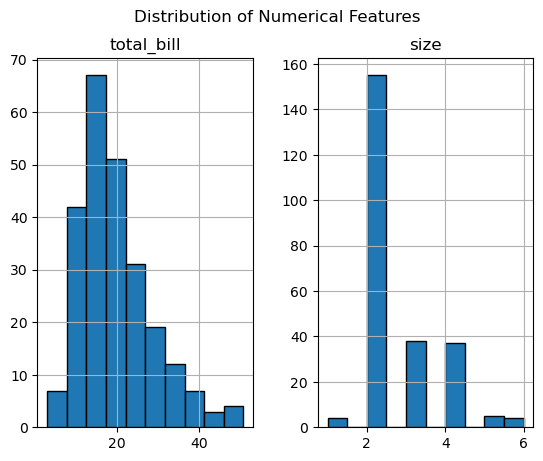

In [88]:
df[["total_bill", "size"]].hist(bins=10, edgecolor = "black")
plt.suptitle("Distribution of Numerical Features")
plt.show()

In [89]:
categorical_columns = ["sex", "smoker", "day", "time"]

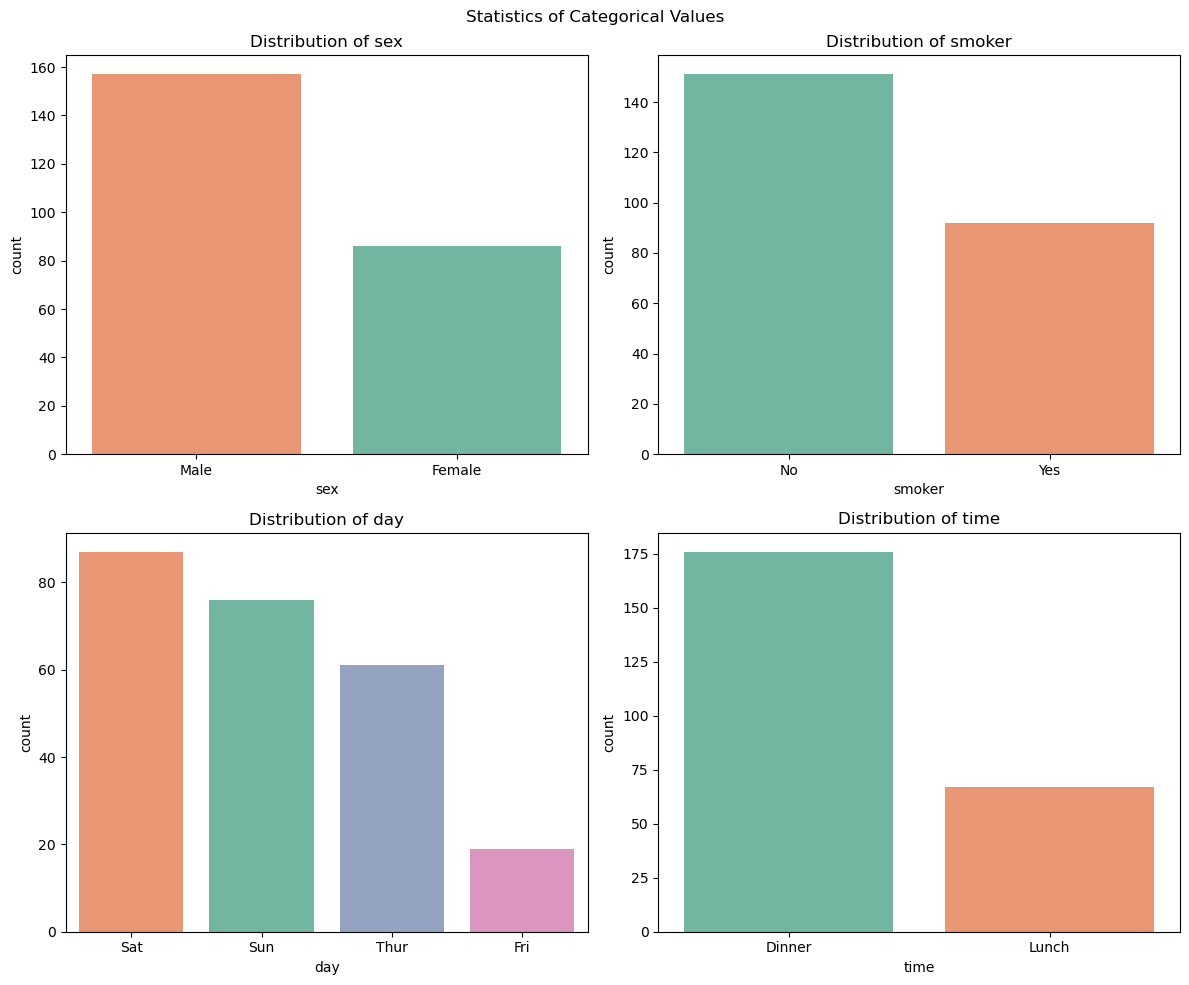

In [90]:
plt.figure(figsize = (12,10))
for i, col in enumerate(categorical_columns):
    plt.subplot(2,2,i+1)
    sns.countplot(data=df, x=col, hue=col, palette="Set2", order=df[col].value_counts().index, legend =False)
    plt.suptitle("Statistics of Categorical Values")
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [91]:
corr = df[["total_bill", "size"]].corr()

In [92]:
corr

,total_bill,size
total_bill,1.000000,0.597589
size,0.597589,1.000000


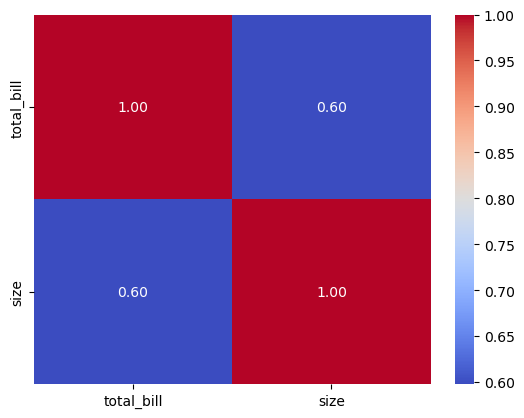

In [93]:
sns.heatmap(corr, annot =True, cmap="coolwarm", fmt=".2f")
plt.show()

In [94]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

In [95]:
features = ["total_bill", "sex", "smoker", "day",  "size"]

In [96]:
target = "tip"

In [97]:
X = df[features].copy()

In [98]:
X

,total_bill,sex,smoker,day,size
0,16.99,Female,No,Sun,2
1,10.34,Male,No,Sun,3
2,21.01,Male,No,Sun,3
3,23.68,Male,No,Sun,2
4,24.59,Female,No,Sun,4
...,...,...,...,...,...
239,29.03,Male,No,Sat,3
240,27.18,Female,Yes,Sat,2
241,22.67,Male,Yes,Sat,2
242,17.82,Male,No,Sat,2


In [99]:
y =df[target]

In [100]:
y

0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 243, dtype: float64

In [101]:
# Applying One-hot encoding
categorical_features = ["sex", "smoker", "day"]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=False, dtype=int
)

In [102]:
categorical_features

['sex', 'smoker', 'day']

In [103]:
X_encoded

,total_bill,size,sex_Female,sex_Male,smoker_No,smoker_Yes,day_Fri,day_Sat,day_Sun,day_Thur
0,16.99,2,1,0,1,0,0,0,1,0
1,10.34,3,0,1,1,0,0,0,1,0
2,21.01,3,0,1,1,0,0,0,1,0
3,23.68,2,0,1,1,0,0,0,1,0
4,24.59,4,1,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
239,29.03,3,0,1,1,0,0,1,0,0
240,27.18,2,1,0,0,1,0,1,0,0
241,22.67,2,0,1,0,1,0,1,0,0
242,17.82,2,0,1,1,0,0,1,0,0


In [104]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size = 0.2, random_state=42)

In [105]:
def evaluate_model(X_train, X_test, y_train, y_test):

    models = { 
        'DecisionTree' : DecisionTreeRegressor(max_depth =5, random_state=42),
        'SVM' : SVR(kernel='rbf'),
        'RandomForest' : RandomForestRegressor(n_estimators=200, random_state=42),
        'XGBoost' : XGBRegressor(objective ="reg:squarederror", random_state=42)
    }

    scores = {}
    trained_models = {}

    for name, model in models.items():

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)

        scores[name] = r2
        trained_models[name]= model

        print(f'{name} : {r2:4f}')

    best_model_name = max(scores, key = scores.get)
    best_model = trained_models[best_model_name]

    print("\nBest Model: ", best_model_name)
    print("Best R2 Score:", round(scores[best_model_name], 4))

    return best_model, best_model_name, scores

In [106]:
best_model, best_model_name, scores = evaluate_model(X_train, X_test, y_train, y_test)

DecisionTree : 0.637560
SVM : 0.429777
RandomForest : 0.509497
XGBoost : 0.509228

Best Model:  DecisionTree
Best R2 Score: 0.6376


In [107]:
best_model.feature_importances_

array([0.80239527, 0.01125186, 0.        , 0.01957445, 0.08065022,
       0.0481959 , 0.        , 0.00433072, 0.0154228 , 0.01817877])

  Original_Feature  Importance
4       total_bill    0.802395
3           smoker    0.128846
0              day    0.037932
1              sex    0.019574
2             size    0.011252


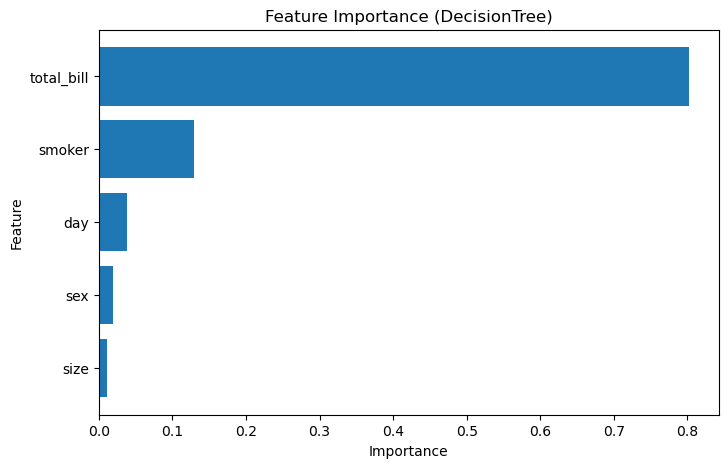

In [108]:

if hasattr(best_model, "feature_importances_"):

    # Getting encoded feature importance
    importance_df = pd.DataFrame({
        "Feature": X_encoded.columns,
        "Importance": best_model.feature_importances_
    })

    # This function maps encoded features back
    def map_to_original_feature(feature):

        for col in categorical_features:
            if feature.startswith(col + "_"):
                return col

        return feature

    # Restoring original feature names
    importance_df["Original_Feature"] = (
        importance_df["Feature"]
        .apply(map_to_original_feature)
    )

    # Aggregating importance
    feature_importance = (
        importance_df
        .groupby("Original_Feature")["Importance"]
        .sum()
        .reset_index()
        .sort_values(by="Importance", ascending=False)
    )

    print(feature_importance)

    # Plotting the visualisation
    plt.figure(figsize=(8, 5))

    plt.barh(
         feature_importance["Original_Feature"],
         feature_importance["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(
        f"Feature Importance ({best_model_name})"
    )

    plt.gca().invert_yaxis()
    plt.show()